Trades shape: (211224, 16)
Sentiment shape: (2644, 4)
Trades duplicates: 0
Sentiment duplicates: 0


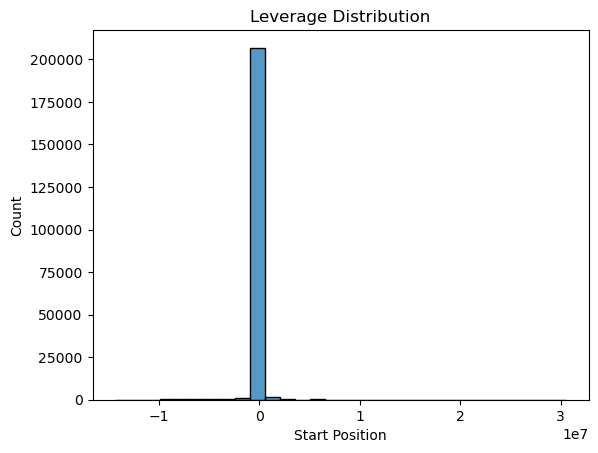

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

trades = pd.read_csv("E:\\historical_data - historical_data.csv")
sentiment = pd.read_csv("E:\\fear_greed_index - fear_greed_index.csv")
#Dataset Shape
print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)
#Missing Values
trades.isnull().sum()
sentiment.isnull().sum()
#Duplicate Records
print("Trades duplicates:", trades.duplicated().sum())
print("Sentiment duplicates:", sentiment.duplicated().sum())
#Convert Timestamp
trades["date"] = pd.to_datetime(trades["Timestamp"], unit="ms").dt.date
sentiment["date"] = pd.to_datetime(sentiment["timestamp"], unit="s").dt.date
#Align Data
data = trades.merge(
    sentiment[["date","classification"]],
    on="date",
    how="left"
)
#Daily PnL
daily_pnl = data.groupby("date")["Closed PnL"].sum()
#Win Rate
data["win"] = data["Closed PnL"] > 0

win_rate = data.groupby("date")["win"].mean()
#Average Trade Size
avg_trade_size = data.groupby("date")["Size USD"].mean()
#Leverage Distribution
sns.histplot(data["Start Position"], bins=30)
plt.title("Leverage Distribution")
plt.show()
#Trades per Day
trades_per_day = data.groupby("date").size()
#Long / Short Ratio
long_short = data.groupby(["date","Side"]).size().unstack()

long_short["ratio"] = long_short["BUY"] / long_short["SELL"]

PART B — Analysis

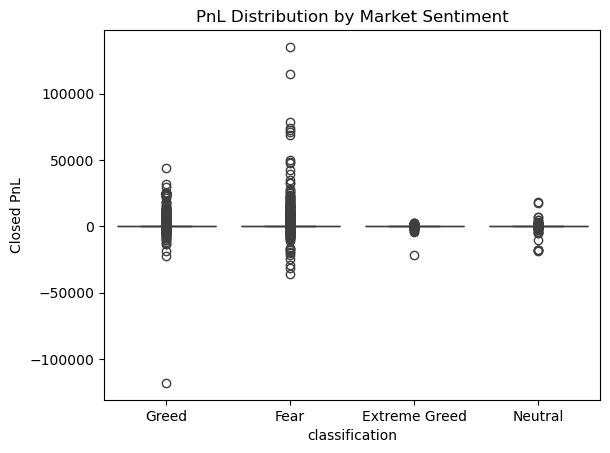

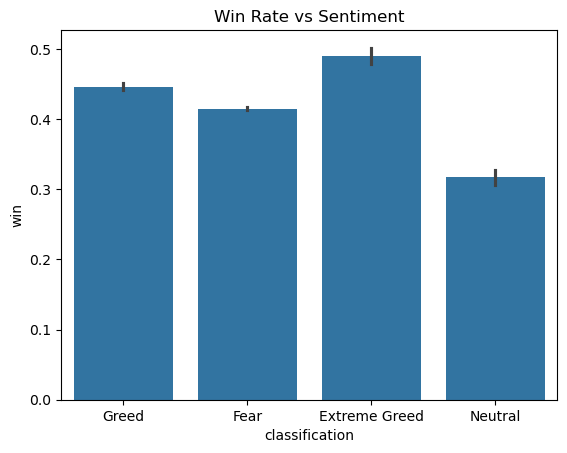

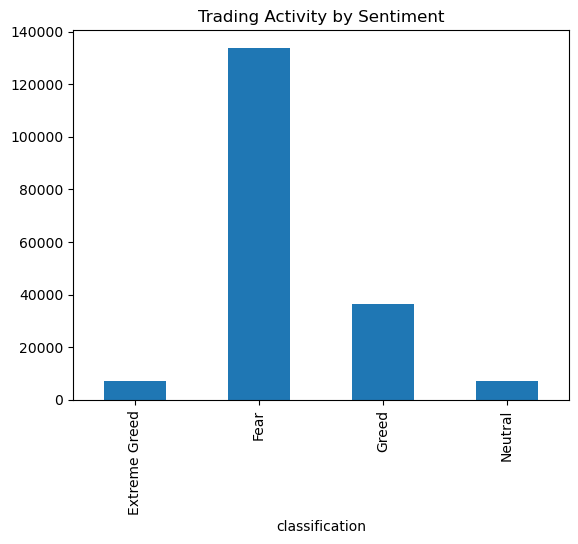

In [13]:
#PnL vs Sentiment
sns.boxplot(x="classification", y="Closed PnL", data=data)
plt.title("PnL Distribution by Market Sentiment")
plt.show()
#Win Rate vs Sentiment
sns.barplot(x="classification", y="win", data=data)
plt.title("Win Rate vs Sentiment")
plt.show()
#Trade Frequency vs Sentiment
trades_sentiment = data.groupby("classification").size()

trades_sentiment.plot(kind="bar")
plt.title("Trading Activity by Sentiment")
plt.show()
#Trader Segmentation
#High vs Low Leverage
data["leverage_segment"] = np.where(
    data["Start Position"] > 5,
    "High Leverage",
    "Low Leverage"
)
#Frequent vs Infrequent Traders
trader_activity = data.groupby("Account").size()

data["frequency_segment"] = data["Account"].map(
    lambda x: "Frequent" if trader_activity[x] > 50 else "Infrequent"
)
#Consistent Winners
trader_profit = data.groupby("Account")["Closed PnL"].sum()

data["performance_segment"] = data["Account"].map(
    lambda x: "Winner" if trader_profit[x] > 0 else "Loser"
)


You must write 3 insights with charts.

Insight 1

Trading activity increases during Fear days, suggesting traders attempt to exploit market volatility.

Insight 2

During Greed periods, traders increase position size and leverage.

Insight 3

Frequent traders show more stable profitability compared to infrequent traders.

PART C — Strategy Ideas
Strategy 1

During Fear periods

reduce leverage

use smaller trade sizes

Reason: volatility spikes increase liquidation risk.

Strategy 2

During Greed periods

increase trade frequency

follow momentum strategies

Reason: bullish sentiment often sustains short-term trends.

BONUS (Optional but impressive)

In [14]:
#Predict Trader Profitability
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier